In [1]:
K_to_eV = 8.617333262E-5
temperature_K = 1600
T_in_eV = K_to_eV*temperature_K

import numpy as np
import matplotlib.pyplot as plt
import ase.io

In [2]:
all_idx_sample = np.arange(170)
num_atoms = 1125


In [3]:
print(T_in_eV/num_atoms, T_in_eV)

0.0001225576286151111 0.137877332192


In [ ]:
all_logp_forward = []
all_logp_backward = []
all_ex = []
all_Uzs = []
all_volumes = []
for i in range(len(all_idx_sample)):
    idx_sample = all_idx_sample[i]
    logp_forward = np.loadtxt(f"./data/Logp_{idx_sample}.txt")
    # logp_backward = np.loadtxt(f"./data/reverse_Logp_{idx_sample}.txt")
    ex = np.loadtxt(f"./data/all_energy_atoms_{idx_sample}.dat")
    Uzs = np.loadtxt(f"./data/Uzs_{idx_sample}.txt")
    all_logp_forward.append(logp_forward)
    # all_logp_backward.append(logp_backward)
    all_ex.append(ex)
    all_Uzs.append(Uzs)

    # atoms = ase.io.read(f"./data/gentraj_{i}.xyz", ":")[-1]
    # all_volumes.append(atoms.get_volume())

all_logp_forward = np.array(all_logp_forward)
all_logp_backward = np.array(all_logp_backward)
all_ex = np.array(all_ex)
all_Uzs = np.array(all_Uzs)
all_volumes = np.array(all_volumes)

In [5]:
ref_volumes = np.loadtxt("/home/tuoping/odefed_mdgen/workdir_odefed_mdgen/data/SiO2/npt_1600K_1GPa/npt_quartz_dense/npt/thermo-lammps.dat")[:,7]

In [6]:
print(all_volumes.shape, ref_volumes.shape)

(0,) (50001,)


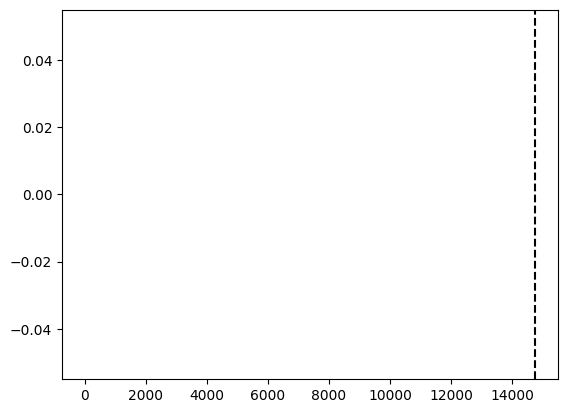

In [7]:
_ = plt.hist(all_volumes, bins=100)
# _ = plt.hist(ref_volumes[::100], bins=100, alpha=0.5)
plt.axvline(ref_volumes.mean(), c="k", ls='--')

In [8]:
ref_ex = np.loadtxt("/home/tuoping/odefed_mdgen/workdir_odefed_mdgen/data/SiO2/npt_1600K_1GPa/npt_quartz_dense/npt/thermo-lammps.dat")[:,2]

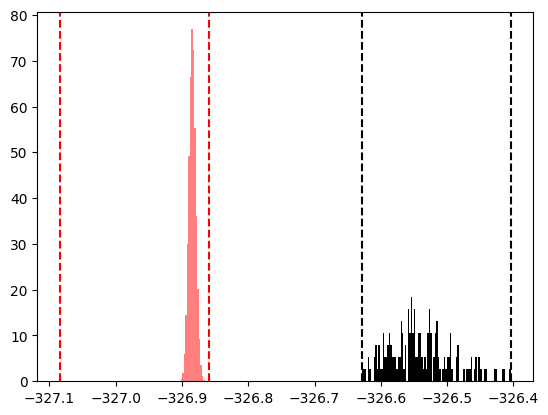

In [9]:
_ = plt.hist(all_ex/num_atoms, bins=100, color='k', density=True)
plt.axvline(all_ex.max()/num_atoms, ls='--', c='k')
plt.axvline(all_ex.min()/num_atoms, ls='--', c='k')

_ = plt.hist(ref_ex/num_atoms, bins=100, alpha=0.5, color='r', density=True)
plt.axvline(ref_ex.max()/num_atoms, ls='--', c='r')
plt.axvline(ref_ex.min()/num_atoms, ls='--', c='r')

In [ ]:

_Ediff_forward = []
work_forward = []

_Ediff_backward = []
work_backward = []
for i in range(len(all_ex)):
    U_b = all_ex[i]/T_in_eV
    U_a = all_Uzs[i][0]
    # _Ediff_forward.append(U_b - U_a  + (-U_a+all_Uzs[i,1]))
    # work_forward.append(U_b - U_a  + (-U_a+all_Uzs[i,1]) + all_logp_forward[i])
    # _Ediff_backward.append(all_Uzs[i][1]-U_b  + (all_Uzs[i,1]-all_Uzs[i,0]))  
    # work_backward.append(all_Uzs[i][1]-U_b  + (all_Uzs[i,1]-all_Uzs[i,0]) + all_logp_backward[i])
    _Ediff_forward.append(U_b - U_a)
    work_forward.append(U_b - U_a + (all_logp_forward[i,0] - all_logp_forward[i,1]/2))

    # _Ediff_backward.append(all_Uzs[i][1]-U_b)  
    # work_backward.append(all_Uzs[i][1]-U_b + (all_logp_backward[i,0] + all_logp_backward[i,1]/2))

_Ediff_backward = np.array(_Ediff_backward)
_Ediff_forward = np.array(_Ediff_forward)
work_forward = np.array(work_forward)
work_backward = np.array(work_backward)

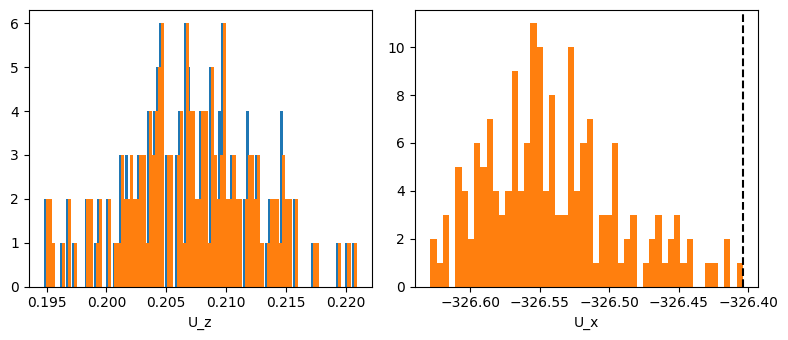

In [11]:
fig, ax = plt.subplots(1,2,figsize=(8,3.5))

_ = ax[0].hist(all_Uzs[:, 0]*T_in_eV/num_atoms, bins=100)
_ = ax[0].hist(all_Uzs[:, 1]*T_in_eV/num_atoms, bins=100)
ax[0].set_xlabel(r"U_z")

_ = ax[1].hist(all_ex/num_atoms, bins=50)
_ = ax[1].hist(all_ex/num_atoms, bins=50)
ax[1].axvline(all_ex.max()/num_atoms, ls='--', c='k')
ax[1].set_xlabel(r"U_x")

plt.tight_layout()

In [12]:
print(all_ex.max(), all_ex.min(), all_ex.mean())

-367204.33273361996 -367457.36732001184 -367357.841962067


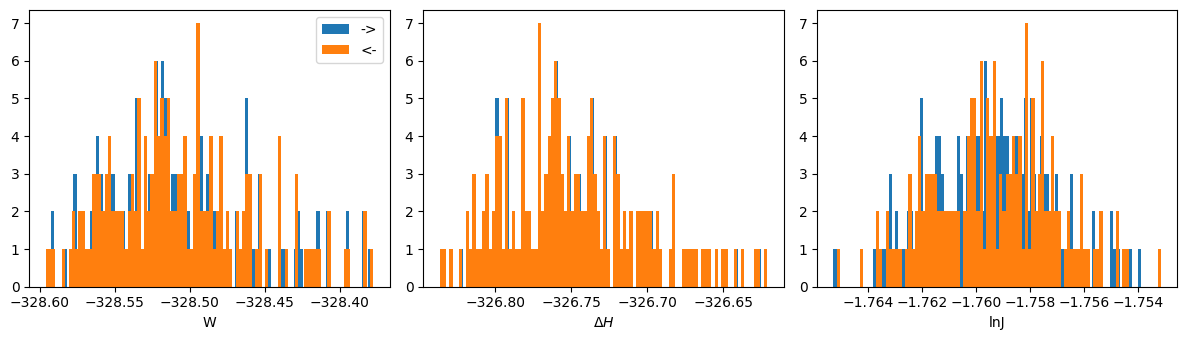

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(12,3.5))
_ = ax[0].hist(work_forward*T_in_eV/num_atoms, bins=100, label="->")
# _ = ax[0].hist(-work_backward*T_in_eV/num_atoms, bins=100, label='<-')
ax[0].legend()

_ = ax[1].hist(_Ediff_forward*T_in_eV/num_atoms, bins=100)
# _ = ax[1].hist(-_Ediff_backward*T_in_eV/num_atoms, bins=100)

_ = ax[2].hist((all_logp_forward[:,0] - all_logp_forward[:,1]/2)*T_in_eV/num_atoms, bins=100)
# _ = ax[2].hist(-((all_logp_backward[:,0] + all_logp_backward[:,1]/2))*T_in_eV/num_atoms, bins=100)

ax[0].set_xlabel(r"W")
ax[1].set_xlabel(r"$\Delta H$")
ax[2].set_xlabel(r"lnJ")
plt.tight_layout()

In [ ]:
from scipy.special import logsumexp
# ELBO = (logsumexp(work_backward) - np.log(len(work_backward)))
EUBO = -(logsumexp(-work_forward) - np.log(len(work_forward)))

sigma = np.sqrt(K_to_eV*temperature_K)
f0_analytic = -0.5 * 3 * np.log(2*np.pi*sigma**2)*num_atoms

print((EUBO+f0_analytic)*T_in_eV/num_atoms)

-328.5659169075471 -328.5647503871943


In [ ]:
print(EUBO*T_in_eV/num_atoms, f0_analytic*T_in_eV/num_atoms)

-328.5955978614733 -328.5944313411206 0.029680953926267344


In [ ]:

def effective_sample_size_from_log_weights(logw):
    """
    Effective sample size of exponential weights.
    """
    logw = np.asarray(logw, dtype=np.float64)
    a = logw - np.max(logw)
    w = np.exp(a)
    return w.sum() ** 2 / np.sum(w ** 2)

print(effective_sample_size_from_log_weights(-work_forward))
# print(effective_sample_size_from_log_weights(work_backward))


def weight_diagnostics(logw, name=""):
    logw = np.asarray(logw, dtype=np.float64)

    log_norm = logsumexp(logw)
    logp = logw - log_norm
    p = np.exp(logp)

    idx = np.argsort(p)[::-1]

    print(f"\n{name}")
    print("N:", len(logw))
    print("ESS:", np.exp(2 * logsumexp(logw) - logsumexp(2 * logw)))
    print("largest weight fraction:", p[idx[0]])
    print("top 5 weight fractions:", p[idx[:5]])
    print("number of samples for 50% weight:", np.searchsorted(np.cumsum(p[idx]), 0.5) + 1)
    print("number of samples for 90% weight:", np.searchsorted(np.cumsum(p[idx]), 0.9) + 1)
    print("dominant indices:", idx[:10])

weight_diagnostics(-work_forward, "forward FEP weights")
# weight_diagnostics(work_backward, "backward FEP weights")

1.000000041836703
1.0000000000000209

forward FEP weights
N: 170
ESS: 1.0000000419095167
largest weight fraction: 0.9999999790452423
top 5 weight fractions: [9.99999979e-01 2.09183426e-08 8.43722764e-15 4.44791899e-44
 1.18769574e-57]
number of samples for 50% weight: 1
number of samples for 90% weight: 1
dominant indices: [ 78  25 116 135  91  51 108  92 130  58]

backward FEP weights
N: 170
ESS: 1.0
largest weight fraction: 1.0
top 5 weight fractions: [1.00000000e+00 1.05387441e-14 4.85133604e-18 9.05295949e-47
 1.64134900e-61]
number of samples for 50% weight: 1
number of samples for 90% weight: 1
dominant indices: [ 78  25 116 135  91  51 108  92 130  58]


In [ ]:
def inspect_dominant(logw, work, name=""):
    logw = np.asarray(logw, dtype=np.float64)
    work = np.asarray(work, dtype=np.float64)

    idx = np.argsort(logw)[::-1]

    print(f"\n{name}")
    print("top indices:", idx[:10])
    print("top log weights:", logw[idx[:10]])
    print("top work values:", work[idx[:10]])
    print("logw gap 1st-2nd:", logw[idx[0]] - logw[idx[1]])

inspect_dominant(-work_forward, work_forward, "forward")
# inspect_dominant(work_backward, work_backward, "backward")


forward
top indices: [ 78  25 116 135  91  51 108  92 130  58]
top log weights: [2681147.34664408 2681129.66400467 2681114.94052148 2681047.52533635
 2681016.27130887 2681004.75732779 2680995.54792371 2680989.38135905
 2680976.521353   2680970.92169207]
top work values: [-2681147.34664408 -2681129.66400467 -2681114.94052148 -2681047.52533635
 -2681016.27130887 -2681004.75732779 -2680995.54792371 -2680989.38135905
 -2680976.521353   -2680970.92169207]
logw gap 1st-2nd: 17.682639406062663

backward
top indices: [ 78  25 116 135  91  51 108  92 130  58]
top log weights: [2681156.86478153 2681124.68106352 2681116.997504   2681050.84637388
 2681016.90260932 2681012.2310102  2680999.27479806 2680980.14862246
 2680977.60166573 2680970.57812804]
top work values: [2681156.86478153 2681124.68106352 2681116.997504   2681050.84637388
 2681016.90260932 2681012.2310102  2680999.27479806 2680980.14862246
 2680977.60166573 2680970.57812804]
logw gap 1st-2nd: 32.18371801171452


In [ ]:
C = (EUBO)
print(C*T_in_eV/num_atoms)

-328.595014601297


In [ ]:
from scipy.optimize import brentq
def log_fermi(x):
    # log(1 / (1 + exp(x))) = -log(1 + exp(x))
    return -np.logaddexp(0.0, x)

def residual(C):
    """
    Root condition:
    sum_F f(wF - C) = sum_B f(-wB + C)
    where f(x) = 1 / (1 + exp(x)).
    """
    log_left = logsumexp(log_fermi(work_forward - C))
    log_right = logsumexp(log_fermi(-work_backward + C))
    return log_left - log_right



-328.595014601297 98.46255425856084


In [23]:
AMU_TO_KG = 1.66053906660e-27
EV_TO_J = 1.602176634e-19
H_PLANCK = 6.62607015e-34            # eV s

import math
def thermal_debroglie_A(mass_amu, temperature_K):
    """
    Thermal de Broglie wavelength in Angstrom:
        Lambda = h / sqrt(2 pi m k_B T)
    """
    mass_kg = mass_amu * AMU_TO_KG
    kBT_J = K_to_eV * temperature_K * EV_TO_J
    Lambda_m = H_PLANCK / math.sqrt(2.0 * math.pi * mass_kg * kBT_J)
    return Lambda_m * 1e10  # meter -> Angstrom



In [ ]:
F_forward_ens = -logsumexp(-all_Uzs[:,0])
print(F_forward_ens*T_in_eV/num_atoms)

0.19471315366258785 0.19487215890774276


In [ ]:
print((F_forward_ens + C)*T_in_eV/num_atoms)

-328.40030144763443 -328.2338818717702
